In [86]:
!pip install -q xgboost lightgbm shap

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Libraries loaded.")

Libraries loaded.


In [87]:

train      = pd.read_csv("dataset_A_training.csv")
test       = pd.read_csv("dataset_A_testing.csv")

TARGET = "seasonal_vaccine"
ID     = "respondent_id"
print("train:", train.shape, "| test:", test.shape)
train.head()

train: (4756, 31) | test: (4749, 30)


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,4.0,2.0,18 - 34 Years,12 Years,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,4.0,4.0,18 - 34 Years,Some College,White,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,2.0,1.0,65+ Years,College Graduate,White,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,NaN,0.0,0.0,0.0,1.0,3.0,3.0,1.0,55 - 64 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,NaN,3.0,1.0,1.0,55 - 64 Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0


In [88]:
print("Shape:", train.shape)
print("\nColumn dtypes:")
print(train.dtypes.value_counts())
print("\nDuplicate respondent_id?", train[ID].duplicated().any())
display(train.describe(include="all").T.head(35))

Shape: (4756, 31)

Column dtypes:
float64    19
object     10
int64       2
Name: count, dtype: int64

Duplicate respondent_id? False


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
respondent_id,4756.0,NaN,NaN,NaN,2378.5,1373.08327,1.0,1189.75,2378.5,3567.25,4756.0
flu_concern,4744.0,NaN,NaN,NaN,1.643128,0.91981,0.0,1.0,2.0,2.0,3.0
flu_knowledge,4733.0,NaN,NaN,NaN,1.293049,0.618902,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,4742.0,NaN,NaN,NaN,0.052299,0.222652,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,4724.0,NaN,NaN,NaN,0.734124,0.441846,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,4753.0,NaN,NaN,NaN,0.073848,0.261551,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,4748.0,NaN,NaN,NaN,0.836563,0.369803,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,4747.0,NaN,NaN,NaN,0.365494,0.481619,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,4747.0,NaN,NaN,NaN,0.336634,0.472608,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,4737.0,NaN,NaN,NaN,0.68841,0.463192,0.0,0.0,1.0,1.0,1.0


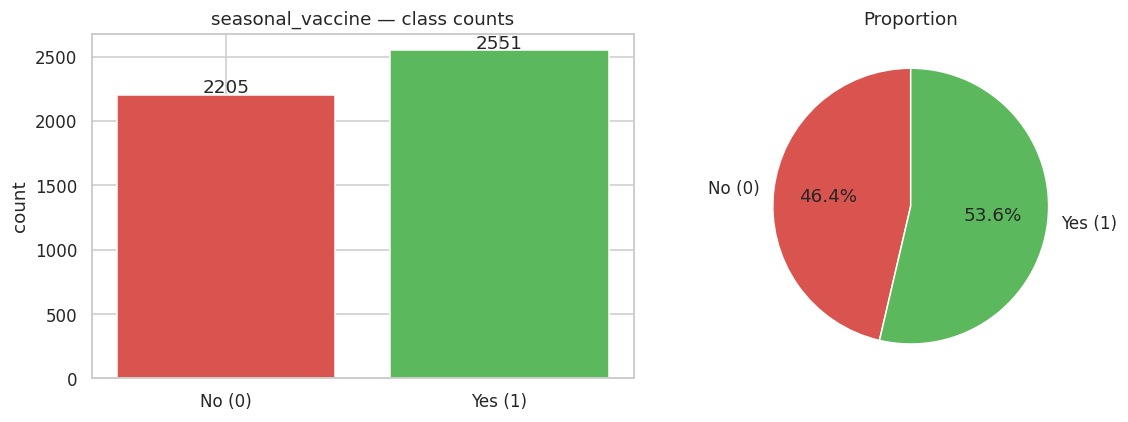

Positive rate = 0.536  ->  classes are well balanced.


In [89]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts = train[TARGET].value_counts().sort_index()
ax[0].bar(["No (0)", "Yes (1)"], counts.values, color=["#d9534f", "#5cb85c"])
ax[0].set_title("seasonal_vaccine — class counts"); ax[0].set_ylabel("count")
for i, v in enumerate(counts.values): ax[0].text(i, v+15, str(v), ha="center")
ax[1].pie(counts.values, labels=["No (0)", "Yes (1)"], autopct="%1.1f%%",
          colors=["#d9534f", "#5cb85c"], startangle=90)
ax[1].set_title("Proportion")
plt.tight_layout(); plt.show()
print(f"Positive rate = {train[TARGET].mean():.3f}  ->  classes are well balanced.")

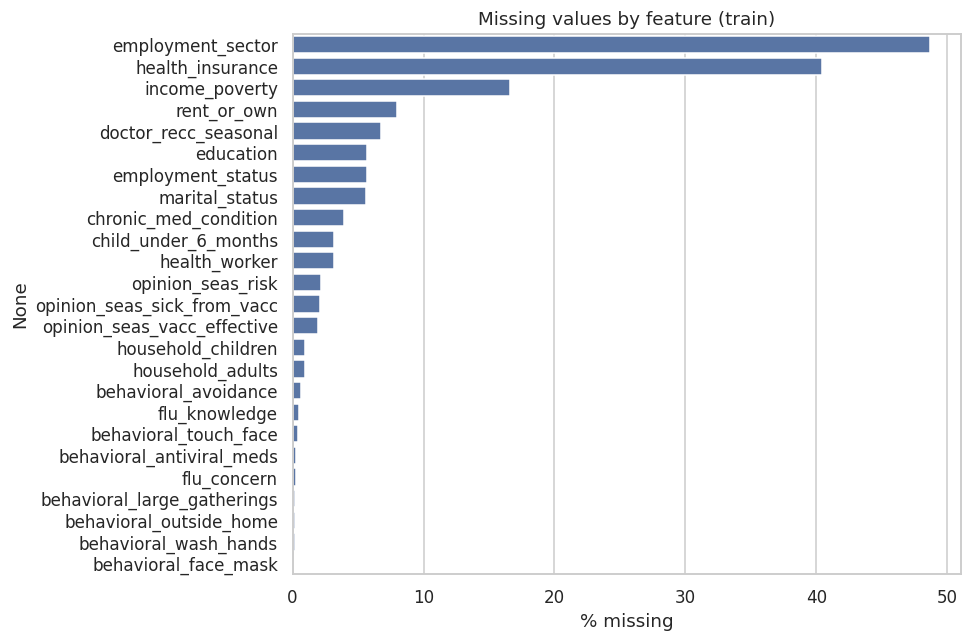

,percent_missing
employment_sector,48.7
health_insurance,40.5
income_poverty,16.6
rent_or_own,8.0
doctor_recc_seasonal,6.7
education,5.7
employment_status,5.7
marital_status,5.6
chronic_med_condition,4.0
child_under_6_months,3.2


In [90]:
miss = (train.isnull().mean()*100).sort_values(ascending=False)
miss = miss[miss > 0]
plt.figure(figsize=(9, 6))
sns.barplot(x=miss.values, y=miss.index, color="#4c72b0")
plt.xlabel("% missing"); plt.title("Missing values by feature (train)")
plt.tight_layout(); plt.show()
display(miss.round(1).to_frame("percent_missing"))

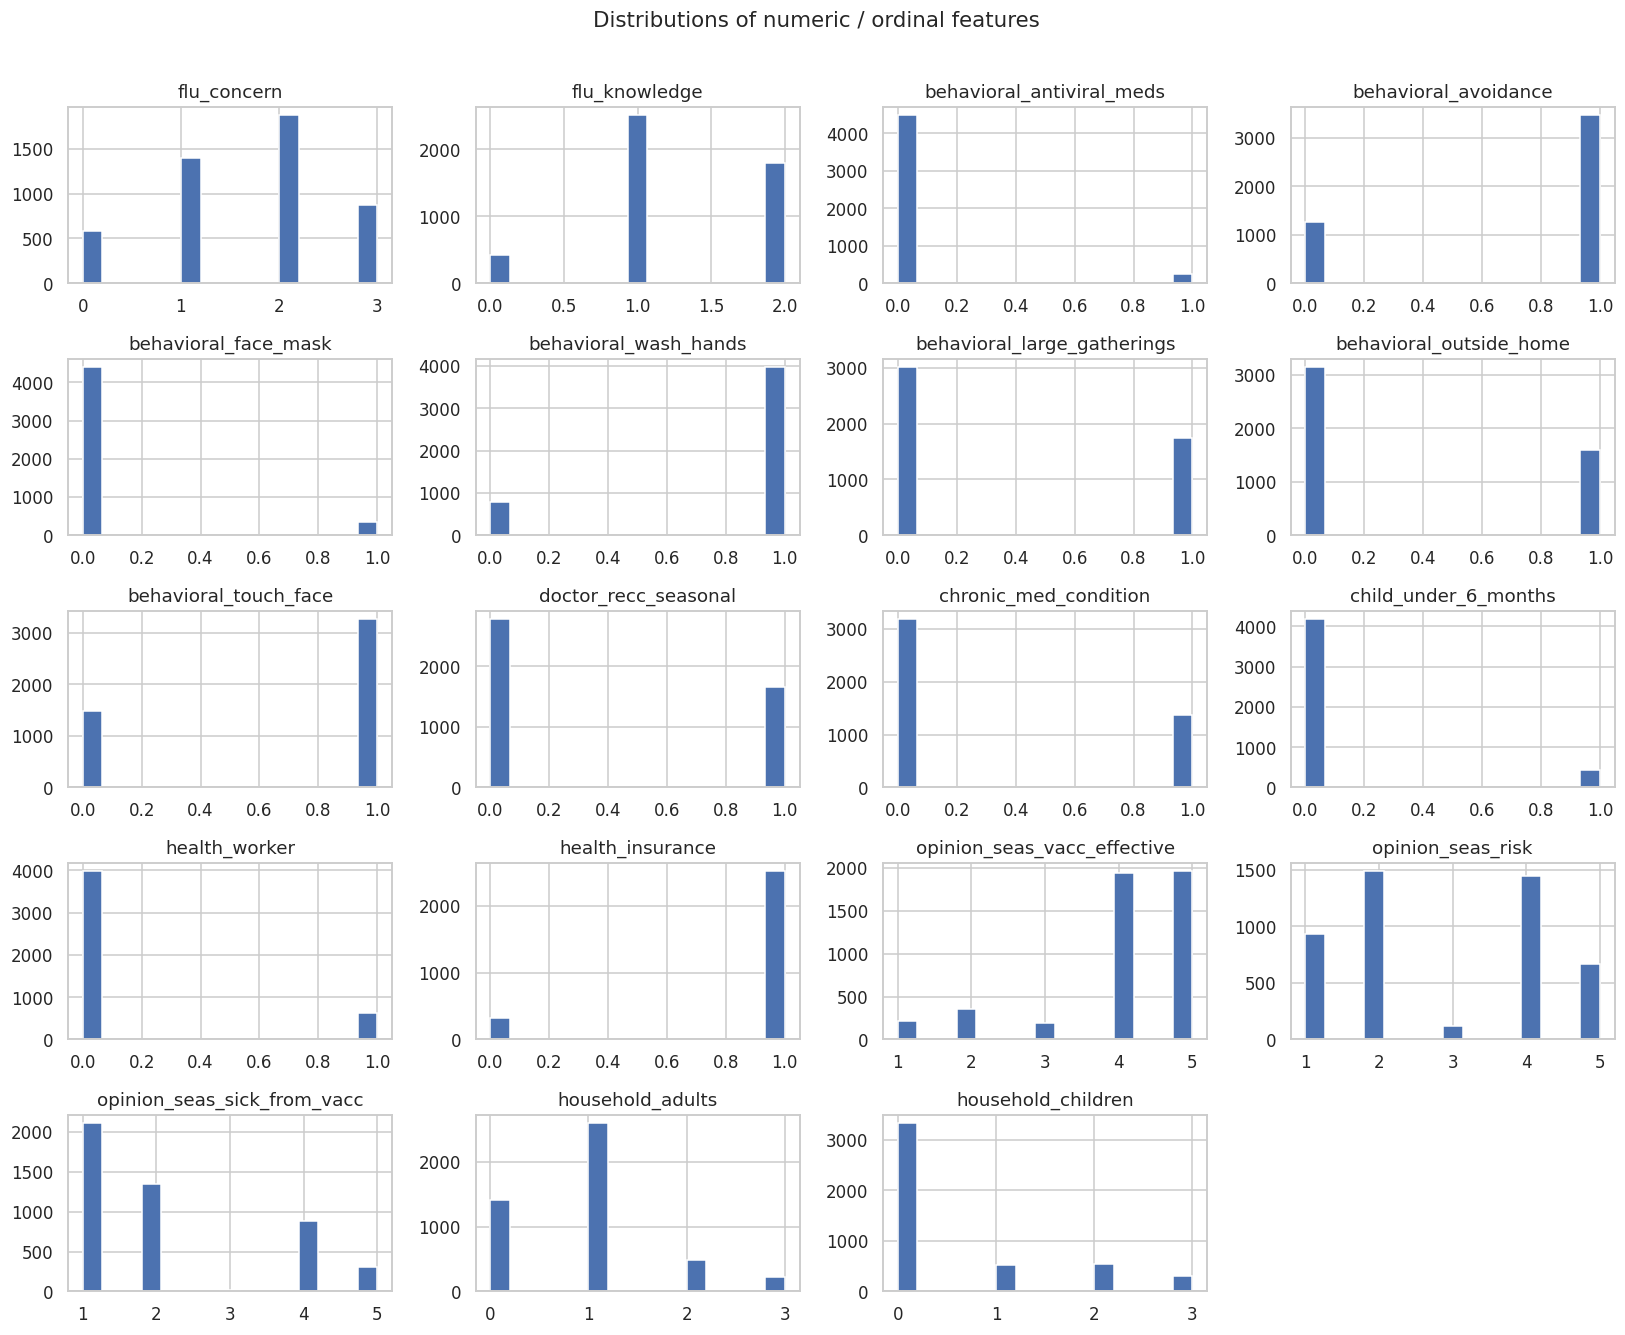

In [91]:
num_cols = train.select_dtypes(include=np.number).drop(columns=[ID, TARGET]).columns.tolist()
train[num_cols].hist(figsize=(15, 12), bins=15, color="#4c72b0", edgecolor="white")
plt.suptitle("Distributions of numeric / ordinal features", y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

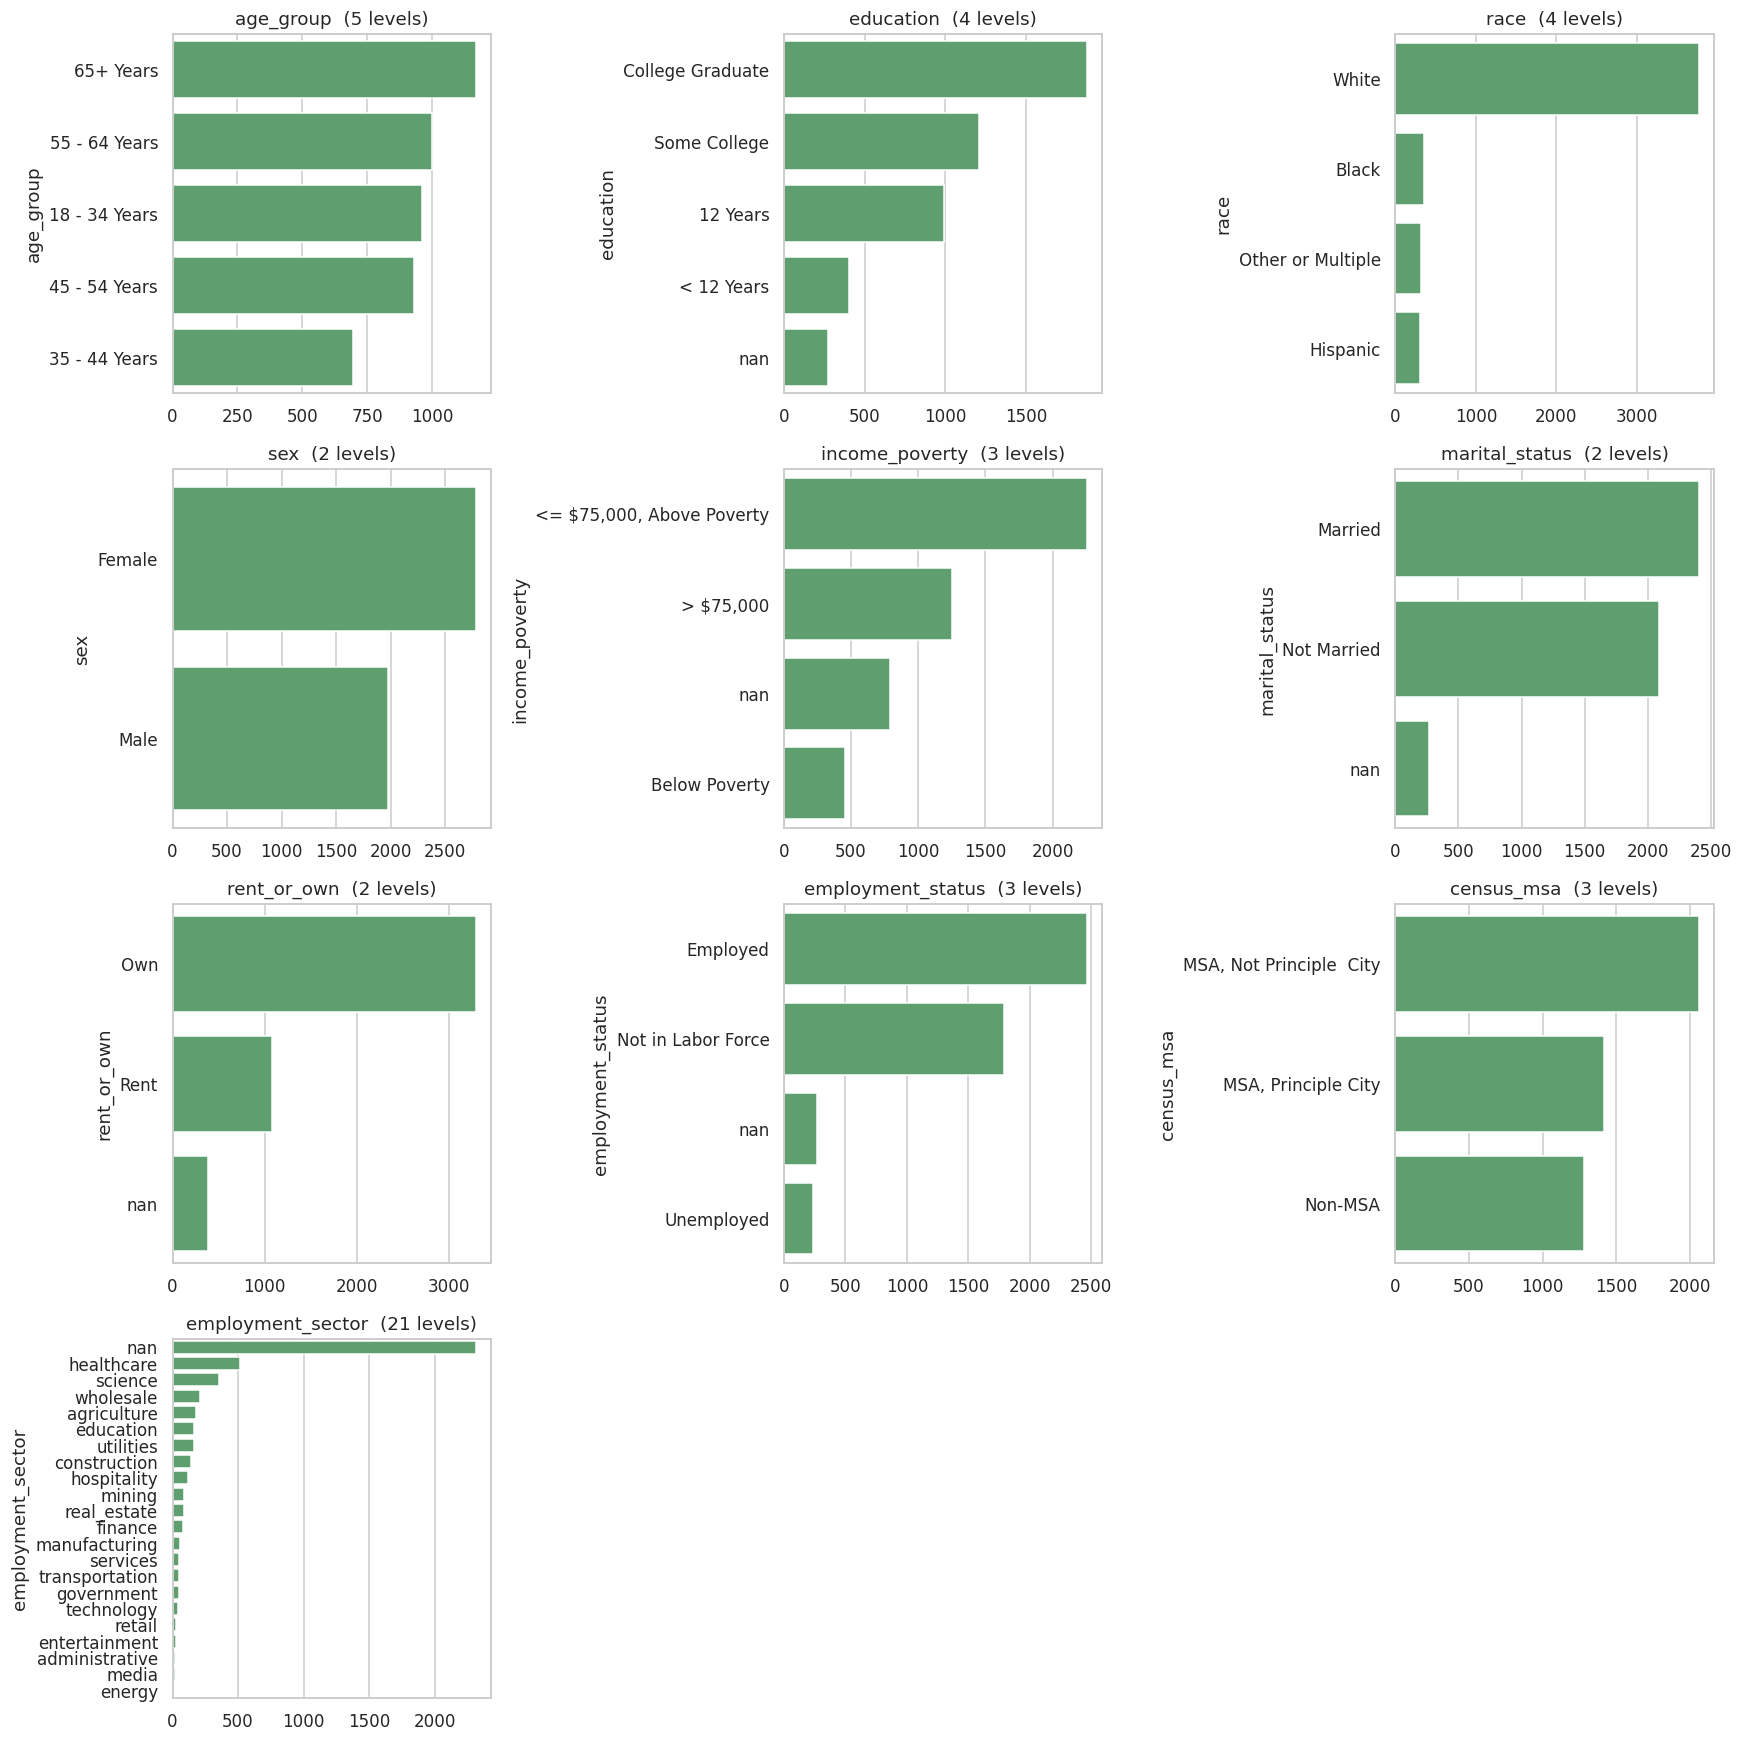

In [92]:
cat_cols = train.select_dtypes(include="object").columns.tolist()
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
for ax, c in zip(axes.ravel(), cat_cols):
    vc = train[c].value_counts(dropna=False)
    sns.barplot(x=vc.values, y=vc.index.astype(str), ax=ax, color="#55a868")
    ax.set_title(f"{c}  ({train[c].nunique()} levels)"); ax.set_xlabel("")
for ax in axes.ravel()[len(cat_cols):]: ax.axis("off")
plt.tight_layout(); plt.show()

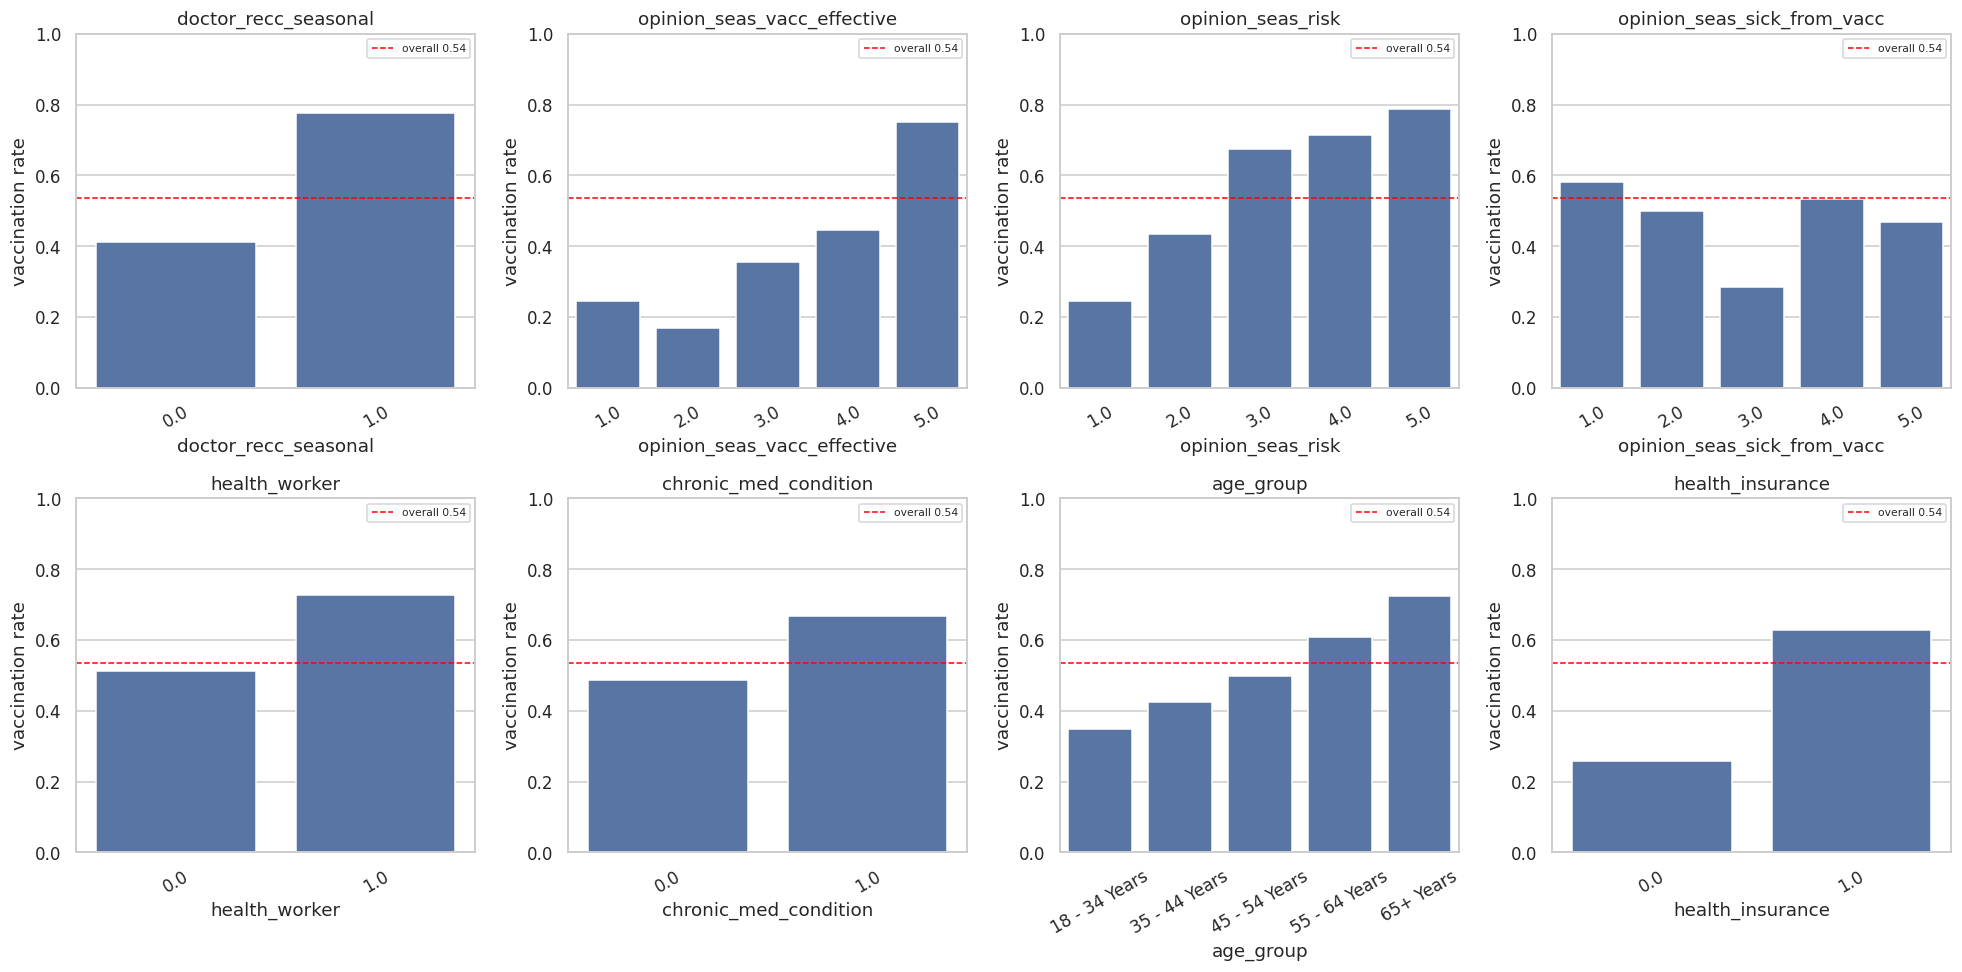

In [93]:
baseline = train[TARGET].mean()
drivers = ["doctor_recc_seasonal", "opinion_seas_vacc_effective", "opinion_seas_risk",
           "opinion_seas_sick_from_vacc", "health_worker", "chronic_med_condition",
           "age_group", "health_insurance"]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, c in zip(axes.ravel(), drivers):
    rate = train.groupby(c)[TARGET].mean().sort_index()
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax, color="#4c72b0")
    ax.axhline(baseline, color="red", ls="--", lw=1, label=f"overall {baseline:.2f}")
    ax.set_title(c); ax.set_ylabel("vaccination rate"); ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

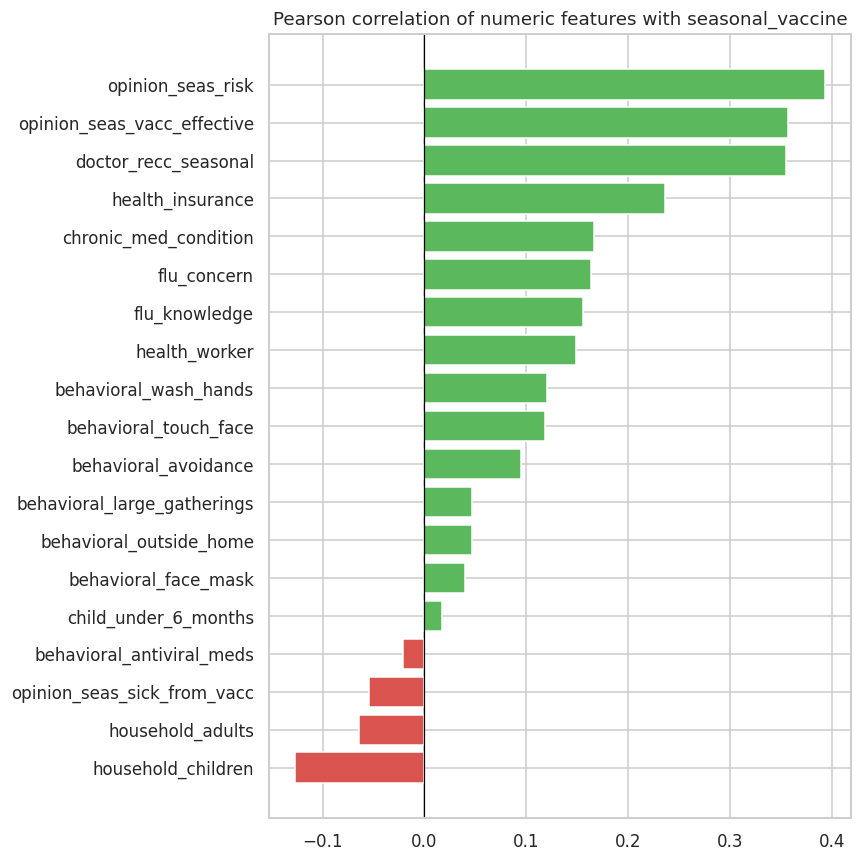

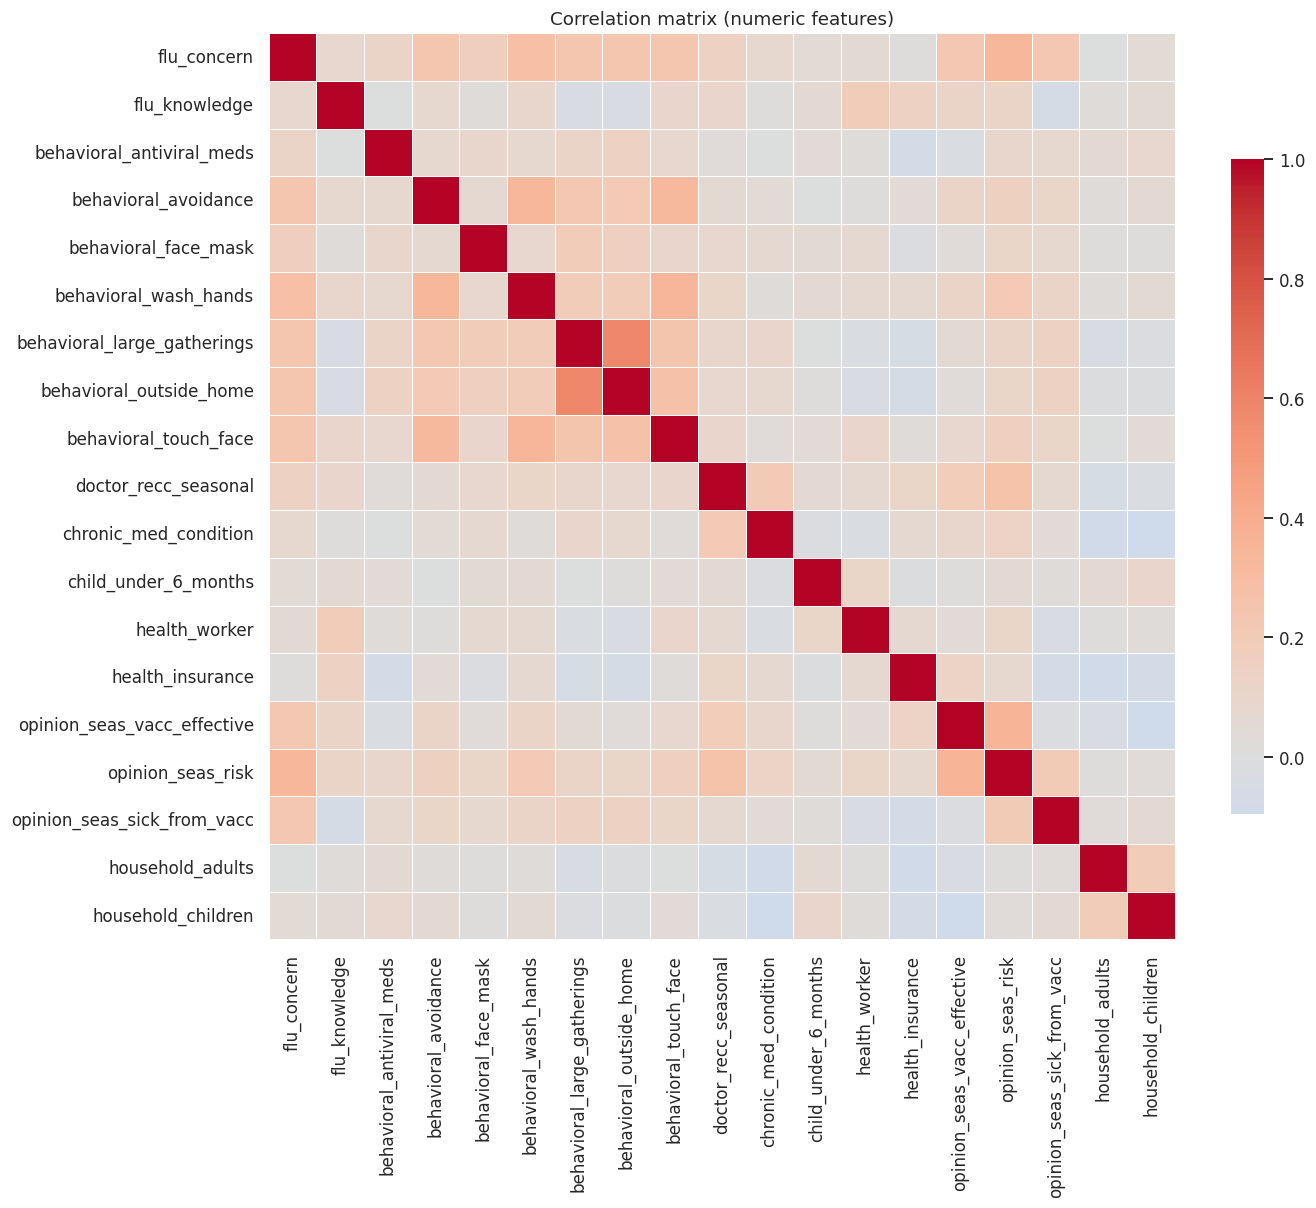

In [94]:
corr_target = train[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
plt.figure(figsize=(8, 8))
colors = ["#d9534f" if v < 0 else "#5cb85c" for v in corr_target.values]
plt.barh(corr_target.index, corr_target.values, color=colors)
plt.title("Pearson correlation of numeric features with seasonal_vaccine")
plt.axvline(0, color="black", lw=0.8); plt.tight_layout(); plt.show()

plt.figure(figsize=(13, 11))
sns.heatmap(train[num_cols].corr(), cmap="coolwarm", center=0, square=True,
            linewidths=.4, cbar_kws={"shrink": .7})
plt.title("Correlation matrix (numeric features)"); plt.tight_layout(); plt.show()

In [95]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


ORDINAL_MAPS = {
    "age_group":      {"18 - 34 Years": 0, "35 - 44 Years": 1, "45 - 54 Years": 2,
                       "55 - 64 Years": 3, "65+ Years": 4},
    "education":      {"< 12 Years": 0, "12 Years": 1, "Some College": 2, "College Graduate": 3},
    "income_poverty": {"Below Poverty": 0, "<= $75,000, Above Poverty": 1, "> $75,000": 2},
}
NOMINAL = ["race", "sex", "marital_status", "rent_or_own",
           "employment_status", "census_msa", "employment_sector"]

def prepare(df):

    df = df.drop(columns=[c for c in [ID, TARGET] if c in df.columns]).copy()
    for col, mapping in ORDINAL_MAPS.items():
        df[col] = df[col].map(mapping)
    for col in NOMINAL:
        df[col] = df[col].fillna("Missing")
    return df

X      = prepare(train)
X_test = prepare(test)
y      = train[TARGET].astype(int)
test_ids = test[ID]

NUMERIC = [c for c in X.columns if c not in NOMINAL]
print(f"{len(NUMERIC)} numeric/ordinal features, {len(NOMINAL)} nominal features")

def build_preprocessor(scale=False):
    num_steps = [("impute", SimpleImputer(strategy="median", add_indicator=True))]
    if scale:
        num_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(num_steps), NUMERIC),
        ("cat", OneHotEncoder(handle_unknown="ignore"), NOMINAL),
    ])


_demo = build_preprocessor().fit(X, y)
print("Feature matrix after preprocessing:", _demo.transform(X).shape)

22 numeric/ordinal features, 7 nominal features
Feature matrix after preprocessing: (4756, 84)


In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

def make_model(estimator, scale=False):
    return Pipeline([("pre", build_preprocessor(scale)), ("clf", estimator)])

models = {
    "LogReg":       make_model(LogisticRegression(max_iter=2000, C=0.5), scale=True),
    "RandomForest": make_model(RandomForestClassifier(
                        n_estimators=400, min_samples_leaf=3,
                        n_jobs=-1, random_state=RANDOM_STATE)),
    "HistGB":       make_model(HistGradientBoostingClassifier(
                        max_iter=400, learning_rate=0.05, max_leaf_nodes=31,
                        l2_regularization=1.0, random_state=RANDOM_STATE)),
    "XGBoost":      make_model(XGBClassifier(
                        n_estimators=500, learning_rate=0.03, max_depth=4,
                        subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0,
                        eval_metric="auc", random_state=RANDOM_STATE, n_jobs=-1)),
    "LightGBM":     make_model(LGBMClassifier(
                        n_estimators=600, learning_rate=0.02, num_leaves=31,
                        subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0,
                        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)),
}
print("Defined models:", list(models))

Defined models: ['LogReg', 'RandomForest', 'HistGB', 'XGBoost', 'LightGBM']


LogReg          AUC = 0.8469 +/- 0.0039
RandomForest    AUC = 0.8478 +/- 0.0033
HistGB          AUC = 0.8405 +/- 0.0056
XGBoost         AUC = 0.8525 +/- 0.0031
LightGBM        AUC = 0.8483 +/- 0.0029


,mean_auc,std_auc
XGBoost,0.8525,0.0031
LightGBM,0.8483,0.0029
RandomForest,0.8478,0.0033
LogReg,0.8469,0.0039
HistGB,0.8405,0.0056


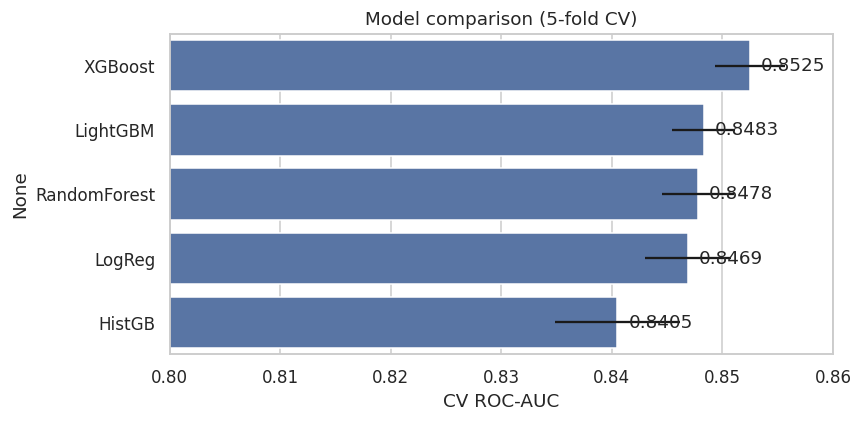

In [97]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:14s}  AUC = {scores.mean():.4f} +/- {scores.std():.4f}")

summary = (pd.DataFrame({k: [v.mean(), v.std()] for k, v in cv_results.items()},
                        index=["mean_auc", "std_auc"]).T
           .sort_values("mean_auc", ascending=False))
display(summary.round(4))

plt.figure(figsize=(8, 4))
order = summary.index
sns.barplot(x=summary.loc[order, "mean_auc"], y=order, color="#4c72b0",
            xerr=summary.loc[order, "std_auc"])
plt.xlim(0.80, 0.86); plt.xlabel("CV ROC-AUC"); plt.title("Model comparison (5-fold CV)")
for i, v in enumerate(summary.loc[order, "mean_auc"]):
    plt.text(v+0.001, i, f"{v:.4f}", va="center")
plt.tight_layout(); plt.show()

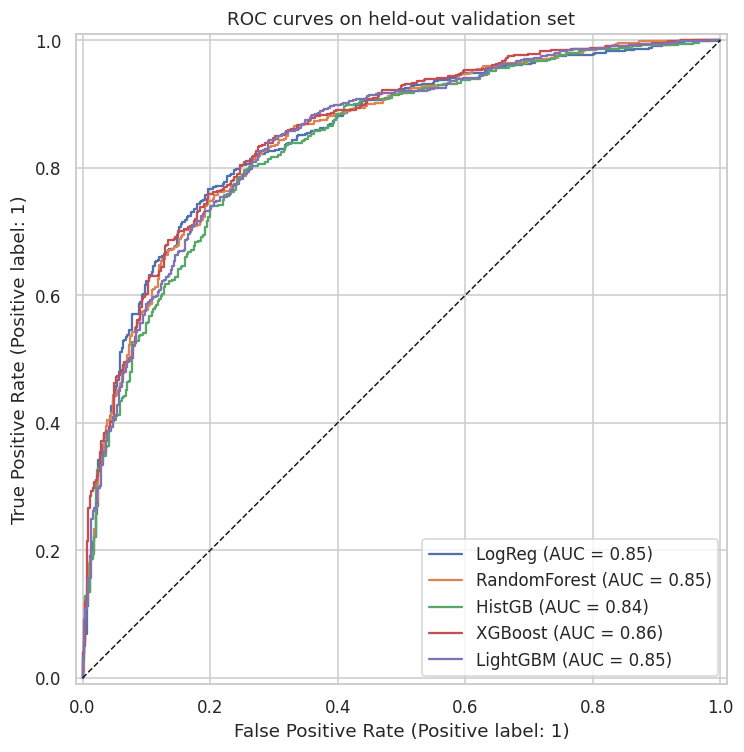

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay, roc_auc_score

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(7, 7))
for name, model in models.items():
    model.fit(X_tr, y_tr)
    RocCurveDisplay.from_estimator(model, X_val, y_val, ax=ax, name=name)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC curves on held-out validation set"); plt.tight_layout(); plt.show()

Best single model: XGBoost
Validation AUC      : 0.8552
Validation accuracy : 0.7721
Validation F1       : 0.7858

              precision    recall  f1-score   support

          No       0.75      0.76      0.76       441
         Yes       0.79      0.78      0.79       511

    accuracy                           0.77       952
   macro avg       0.77      0.77      0.77       952
weighted avg       0.77      0.77      0.77       952



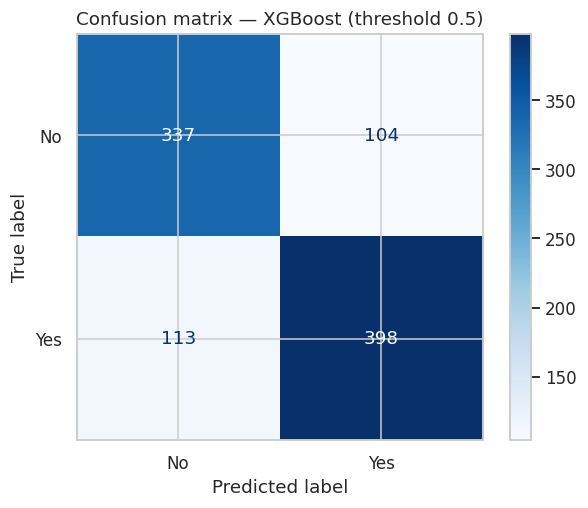

In [99]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, accuracy_score, f1_score)

best_name = summary.index[0]
best_model = models[best_name]
best_model.fit(X_tr, y_tr)
val_proba = best_model.predict_proba(X_val)[:, 1]
val_pred  = (val_proba >= 0.5).astype(int)

print(f"Best single model: {best_name}")
print(f"Validation AUC      : {roc_auc_score(y_val, val_proba):.4f}")
print(f"Validation accuracy : {accuracy_score(y_val, val_pred):.4f}")
print(f"Validation F1       : {f1_score(y_val, val_pred):.4f}\n")
print(classification_report(y_val, val_pred, target_names=["No", "Yes"]))

ConfusionMatrixDisplay(confusion_matrix(y_val, val_pred),
                       display_labels=["No", "Yes"]).plot(cmap="Blues")
plt.title(f"Confusion matrix — {best_name} (threshold 0.5)"); plt.show()

In [100]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

xgb_pipe = make_model(XGBClassifier(
    eval_metric="auc", random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist"))

param_dist = {
    "clf__n_estimators":     randint(300, 900),
    "clf__max_depth":        randint(3, 7),
    "clf__learning_rate":    uniform(0.01, 0.08),
    "clf__subsample":        uniform(0.7, 0.3),
    "clf__colsample_bytree": uniform(0.6, 0.4),
    "clf__reg_lambda":       uniform(0.5, 4.0),
    "clf__min_child_weight": randint(1, 8),
}
search = RandomizedSearchCV(
    xgb_pipe, param_dist, n_iter=25, scoring="roc_auc",
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
search.fit(X, y)
print("\nBest CV AUC :", round(search.best_score_, 4))
print("Best params :")
for k, v in search.best_params_.items():
    print(f"   {k.replace('clf__','')}: {round(v,4) if isinstance(v,float) else v}")
tuned_xgb = search.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best CV AUC : 0.8548
Best params :
   colsample_bytree: 0.7981
   learning_rate: 0.0128
   max_depth: 4
   min_child_weight: 1
   n_estimators: 861
   reg_lambda: 3.1501
   subsample: 0.7935
